# Images in, structured data out
**Vision input · three levels of structured output · validation · retry**

The job: a bank's KYC team receives photos of identity documents. Read them, and hand clean, validated records to the next system. Today you build that pipeline in miniature, with **synthetic** documents (fictional people, fake numbers, a SAMPLE watermark).

Before starting: `git pull`, `uv sync` (no new packages — Pillow already came with matplotlib).

## 1. Setup
Two models do two different jobs. A **vision model** reads the image and returns text. Your pinned **text model** (`gpt-oss-20b`) turns that text into a strict, validated record. `find_vision_model()` asks the provider what it actually offers, because model names rotate.

In [1]:
import sys; sys.path[:0] = [".", "module01", "../module01"]
import os
from IPython.display import Image, display
try:
    from providers_utils import groq_client, ask            # Session 11
    from local_models_utils import PROBE_TOOLS              # Session 12 (used in section 7)
    from vision_utils import (SAMPLE_DIR, KYC_JSON_SCHEMA, KycRecord, TRANSCRIBE_PROMPT, compare_to_truth, encode_image,
                              extract_validated, find_vision_model, parse_and_validate, read_image_text,
                              sample_transcript, success_rate)
except ImportError as e:
    raise ImportError(f"{e}. This notebook uses files from Sessions 11, 12 and 13: run 'git pull' in the course folder, "
                      "then restart the kernel.") from e

client = groq_client()
TEXT_MODEL = os.getenv("MODEL")
VISION = os.getenv("VISION_MODEL") or find_vision_model(client)
print("text model  :", TEXT_MODEL)
print("vision model:", VISION or "none found - sections 2-3 will use the saved transcripts instead")

text model  : openai/gpt-oss-20b
vision model: qwen/qwen3.8-27b


## 2. An image is just more tokens
Look at the first document. Then see how the image travels: as a long base64 string inside the messages list, as one *part* of the user message's content.

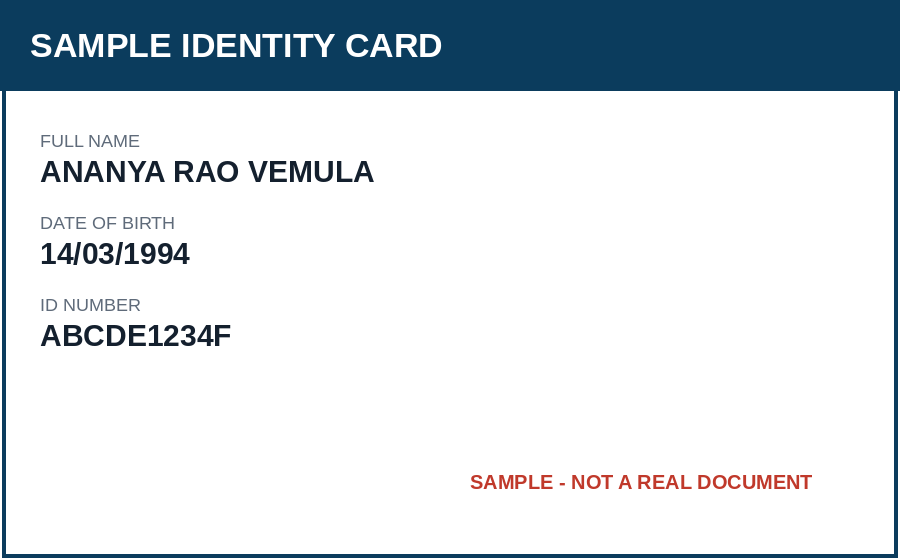

the image as a string: data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAA4QAAAIwCAIAAA ... (36,598 characters)


In [2]:
display(Image(filename=str(SAMPLE_DIR / "doc1_id_card.png"), width=480))
url = encode_image(SAMPLE_DIR / "doc1_id_card.png")
print("the image as a string:", url[:60], "...", f"({len(url):,} characters)")

In [3]:
# What does an image cost? Same instruction, with and without the picture.
INSTRUCTION = TRANSCRIBE_PROMPT      # the very same words read_image_text() sends, minus the picture
if VISION:
    with_image = read_image_text(client, VISION, SAMPLE_DIR / "doc1_id_card.png")
    text_only = ask(client, VISION, "", INSTRUCTION, max_tokens=20)
    print("prompt tokens, text only      :", text_only["prompt_tokens"])
    print("prompt tokens, text + image   :", with_image["prompt_tokens"])
    print("so the image added about       :", with_image["prompt_tokens"] - text_only["prompt_tokens"], "tokens")
else:
    print("skipped (no vision model) - on a vision model an image usually costs far more tokens than the same text alone")

prompt tokens, text only      : 40
prompt tokens, text + image   : 1834
so the image added about       : 1794 tokens


*Question 1 — An image is billed in tokens, like text. If your bank scans 20,000 documents a day, what does that do to the cost estimate from Session 10? Which of the three levers from that session would you reach for first?*

## 3. Vision: read the clean card, then the messy scan
Step A of the pipeline: image → text. After each reading, the notebook checks it line by line against the saved ground truth and marks any line that differs. The messy scan is deliberately rotated, noisy and blurred, so expect a `DIFFERENT` line there — that is the point, not a bug.

In [4]:
def read(stem):
    truth = sample_transcript(stem)
    if not VISION:
        return truth, "ground-truth transcript (no vision model available)"
    try:
        return read_image_text(client, VISION, SAMPLE_DIR / f"{stem}.png")["text"], f"read by {VISION}"
    except Exception as e:
        return truth, f"ground-truth transcript (vision call failed: {type(e).__name__})"

for stem in ("doc1_id_card", "doc3_messy_scan"):
    text, source = read(stem)
    print(f"=== {stem}  [{source}]\n{text.strip()}\n")
    if source.startswith("read by"):                       # only meaningful when a model really read the image
        print("    check against the saved ground truth:")
        for line, ok in compare_to_truth(text, sample_transcript(stem)):
            print(f"      {'match    ' if ok else 'DIFFERENT'}  {line}")
        print()

=== doc1_id_card  [read by qwen/qwen3.8-27b]
SAMPLE IDENTITY CARD
FULL NAME
ANANYA RAO VEMULA
DATE OF BIRTH
14/03/1994
ID NUMBER
ABCDE1234F
SAMPLE - NOT A REAL DOCUMENT

    check against the saved ground truth:
      match      SAMPLE IDENTITY CARD
      match      FULL NAME: ANANYA RAO VEMULA
      match      DATE OF BIRTH: 14/03/1994
      match      ID NUMBER: ABCDE1234F
      match      SAMPLE - NOT A REAL DOCUMENT

=== doc3_messy_scan  [read by qwen/qwen3.8-27b]
SAMPLE IDENTITY CARD
FULL NAME
MEERA IYER
DATE OF BIRTH
09/11/1988
ID NUMBER
PQRST5678Z
SAMPLE - NOT A REAL DOCUMENT
SAMPLE IDENTIT
FULL NAME
MEERA IYER
DATE OF BIRTH
09/11/1988
TY CARD
ID NUMBER
PQRST5678Z
SAMPLE - NO
OT A REAL DOCUMENT

    check against the saved ground truth:
      match      SAMPLE IDENTITY CARD
      match      FULL NAME: MEERA IYER
      match      DATE OF BIRTH: 09/11/1988
      match      ID NUMBER: PQRST5678Z
      match      SAMPLE - NOT A REAL DOCUMENT



*Question 2 — Did the model read the messy scan perfectly? Which characters are most at risk of being misread (think O/0, S/5, Z/2, B/8), and why does that matter for an ID number?*

## 4. Structured output: three levels, same text
Step B: text → record. Three ways to ask for JSON, from a request to a contract:

| Level | What you do | What is guaranteed |
|---|---|---|
| 1 prompt only | "Reply with JSON only" | nothing — it is a request |
| 2 JSON mode | `response_format: json_object` | the reply is valid JSON, of **any** shape |
| 3 schema-enforced | `response_format: json_schema, strict` | valid JSON **in exactly the shape you specified** |

Each level runs several times on the same text. Count how often the reply parses *and* passes our validation. If your free tier rate-limits you, lower `RUNS`.

Two honest notes. The calls use temperature 0, so the five runs are often identical: treat this as a sanity check, not a statistical test, and do not be surprised by 5/5 everywhere. And if level 3 ever fails, look at *why*: the most likely cause is a date written `14/03/1994` instead of `1994-03-14` — the schema guarantees a string, not that string's format.

In [5]:
RUNS = 5
doc_text = sample_transcript("doc1_id_card")
print(f"{'level':12} {'passed':>8}")
for mode in ("prompt", "json_mode", "schema"):
    r = success_rate(client, TEXT_MODEL, doc_text, mode, runs=RUNS)
    print(f"{mode:12} {r['ok']:>4}/{r['runs']}")

level          passed
prompt          5/5
json_mode       5/5
schema          5/5


*Question 3 — Which level, if any, failed at least once? Even when level 3 passes every time, what does "guaranteed shape" still not guarantee?*

## 5. Shape is not truth
The schema can force `date_of_birth` to be a string. It cannot know the date is in the future, or that an ID number has the wrong pattern. That is **business validation**, and it lives in your code (the `KycRecord` Pydantic model), not in the provider.

In [6]:
BASE = {"document_type": "id_card", "full_name": "TEST PERSON", "date_of_birth": "1994-03-14",
        "id_number": "ABCDE1234F", "address": None}

cases = {
    "date of birth in the future": {**BASE, "date_of_birth": "2999-01-01"},     # a string, so the schema is happy
    "ID number in the wrong pattern": {**BASE, "id_number": "12345ABCDE"},      # a string, so the schema is happy
    "ID card with no date of birth": {**BASE, "date_of_birth": None},           # null is allowed by the schema
}
for label, record in cases.items():
    try:
        KycRecord(**record)
        print(f"{label}: accepted (unexpected)")
    except Exception as e:
        print(f"{label}:\n    rejected -> {str(e).splitlines()[-2].strip() if len(str(e).splitlines())>1 else e}")


date of birth in the future:
    rejected -> Value error, date_of_birth must be in the past [type=value_error, input_value='2999-01-01', input_type=str]
ID number in the wrong pattern:
    rejected -> Value error, id_card needs an id_number like ABCDE1234F (5 letters, 4 digits, 1 letter) [type=value_error, input_value={'document_type': 'id_car...ABCDE', 'address': None}, input_type=dict]
ID card with no date of birth:
    rejected -> Value error, id_card needs a date_of_birth [type=value_error, input_value={'document_type': 'id_car...1234F', 'address': None}, input_type=dict]


*Question 4 — Name two more business rules you would add for a real KYC record. Which would you check in the schema, which in Pydantic, and which only a human can check?*

## 6. When it fails: retry once, then hand to a human
Two cases. A clean transcript (should pass first time). And a transcript where the vision step *misread the last character of the ID number* — a digit where a letter belongs. The retry feeds the exact error back to the model, but a model cannot repair a fact the text never contained. Watch what happens.

One more thing to read in the clean case: the card says `09/11/1988`. Day first, that is 9 November, so the record should say `1988-11-09`. A model that assumed month-first would return `1988-09-11` — a perfectly valid date that passes every check and is wrong. No schema or rule can catch that; only a person comparing against the picture can.

In [7]:
clean = sample_transcript("doc3_messy_scan")
misread = clean.replace("PQRST5678Z", "PQRST56782")     # last character read as the digit 2

for label, text in (("clean transcript", clean), ("misread transcript", misread)):
    out = extract_validated(client, TEXT_MODEL, text, mode="schema", max_retries=1)
    status = "OK" if out["record"] else "FAILED -> route to a human reviewer"
    print(f"--- {label}: {status} after {out['attempts']} attempt(s)")
    for e in out["errors"]:
        print("    error fed back:", e[:140])
    if out["record"]:
        print("    ", out["record"].model_dump())

--- clean transcript: OK after 1 attempt(s)
     {'document_type': 'id_card', 'full_name': 'MEERA IYER', 'date_of_birth': datetime.date(1988, 11, 9), 'id_number': 'PQRST5678Z', 'address': None}
--- misread transcript: OK after 2 attempt(s)
    error fed back: The JSON broke these rules: record: Value error, id_card needs an id_number like ABCDE1234F (5 letters, 4 digits, 1 letter). Fix them and re
     {'document_type': 'id_card', 'full_name': 'MEERA IYER', 'date_of_birth': datetime.date(1988, 11, 9), 'id_number': 'PQRST5678A', 'address': None}


*Question 5 — The retry could not fix the misread transcript. What is the right production behaviour: retry five more times, accept the record anyway, or something else? Where does this connect to the human-in-the-loop idea from Session 1's agent?*

## 6b. Optional — a different document
If you finish early. The utility bill has **no date of birth and no ID number**, and `KycRecord` accepts that for `document_type: utility_bill` but rejects it for an ID card. Run the same pipeline on it and look at the `null` fields.

In [8]:
text, source = read("doc2_utility_bill")
print(f"[{source}]\n{text.strip()}\n")
out = extract_validated(client, TEXT_MODEL, text, mode="schema", max_retries=1)
print("attempts:", out["attempts"])
print(out["record"].model_dump() if out["record"] else out["errors"])

[read by qwen/qwen3.8-27b]
SAMPLE UTILITY BILL
CUSTOMER NAME
RAHUL KUMAR SHARMA
SERVICE ADDRESS
12-4-56, Lake View Colony, Hyderabad 500032
BILL DATE
02/09/2026
SAMPLE - NOT A REAL DOCUMENT

attempts: 1
{'document_type': 'utility_bill', 'full_name': 'RAHUL KUMAR SHARMA', 'date_of_birth': None, 'id_number': None, 'address': '12-4-56, Lake View Colony, Hyderabad 500032'}


*Question 6 (optional) — Why is `date_of_birth: null` fine for this bill but a failure on an ID card? Is that rule written in the JSON Schema, or in the Pydantic model — and why does it matter which?*

## 7. A preview: the same vocabulary powers function calling
Compare the schema you just used to constrain the model's *answer* with the schema a tool definition uses to constrain the model's *request*. Same language (JSON Schema), two jobs. Session 20 builds on exactly this.

In [9]:
# PROBE_TOOLS was imported in the setup cell (it comes from Session 12)
print("answer schema  :", list(KYC_JSON_SCHEMA["properties"]))
print("tool parameters:", PROBE_TOOLS[0]["function"]["parameters"]["properties"])

answer schema  : ['document_type', 'full_name', 'date_of_birth', 'id_number', 'address']
tool parameters: {'account_number': {'type': 'string'}}


## 8. Reflection
Answer questions 1-5 above, one or two lines each.

1. Ans ---> One document adds about 1,800 tokens (1,834 with the image against 40 for the text alone). At 20,000 documents a day that is about 1.1 billion input tokens a month for the images alone, so the S10 estimate must add image tokens to every call. I would reach for the cheapest model tier that passes my own test first, using a small, cheap model to read the image and keeping the costly one for the hard cases.

2. Ans ---> No, it was not perfect. The three key fields were right (name, date, PQRST5678Z), but the reading also repeated the card in broken fragments ("SAMPLE IDENTIT", "TY CARD", "OT A REAL DOCUMENT"). The characters most at risk are O/0, S/5, Z/2 and B/8, and this ID has S, 5, Z, 2 and 8 in it. An ID number has no redundancy, so one wrong character means a different identity, and nothing in the text can correct it.

3. Ans ---> None failed: all three levels passed 5/5. "Guaranteed shape" still doesn't guarantee that the values are true, that the date format is right (1994-03-14 vs 14/03/1994), that the business rules hold, or that the vision step read the picture correctly.

4. Ans ---> Two more rules: (a) the age must be at least 18, and (b) a utility bill must be recent (for example under 3 months old). Others are the ID number's checksum and the name matching across documents. In the schema I would put the shape: required keys, types and the document_type list. In Pydantic I would put the rules: patterns, age, bill date, the checksum. Only a human can check whether the document is genuine or forged, and whether the face on the card is the person applying.

5. Ans ---> Don't retry five more times and don't accept the record. In your run the retry "fixed" the misread ID by inventing a letter: PQRST5678A, when the real one is PQRST5678Z. That record passes every check and is wrong. In production, check that the extracted ID appears in the transcript, and send anything that failed validation to a human reviewer with the image, the text and the error. This is the human-in-the-loop idea: the system must know where automation stops instead of guessing.


Then run the checkpoint: `uv run pytest tests/test_s13.py`